In [1]:
"""
Этап 1. Проведите исследовательский анализ (EDA)
1. Загрузите датасет и визуализируйте часть данных. Изучите то, с чем предстоит работать
2. Сформируйте видение:
как вы будете решать задачу,
какие подходы к обогащению/аугментации данных примените и почему,
на какие метрики будете ориентироваться при обучении.
3. Объедините таблицы dish.csv и ingredients.csv.
В колонке ingredients таблицы dish.csv хранятся технические идентификаторы вида ingr_0000000122 — модель не извлечёт из них никакой информации о блюде.  Замените идентификаторы на реальные названия продуктов из ingredients.csv (колонка ingr), чтобы текстовая компонента модели получала осмысленный вход.
Пример: "ingr_0000000122;ingr_0000000026" => "salmon, zucchini".
"""

import pandas as pd

# 1. Загрузите датасет и визуализируйте часть данных. Изучите то, с чем предстоит работать
dish_df = pd.read_csv("data/dish.csv")
print("Dish.csv")
print("Количество элементов датасета:", len(dish_df))
print("Количество элементов тестового датасета:", (dish_df["split"] == "test").sum())
print("Количество элементов тренировочного датасета:", (dish_df["split"] == "train").sum())
print(dish_df.loc[:5])
print("")

ing_df = pd.read_csv("data/ingredients.csv")
print("Ingredients.csv")
print("Количество ингридиентов:", len(ing_df))
print(ing_df.loc[:5])


Dish.csv
Количество элементов датасета: 3262
Количество элементов тестового датасета: 507
Количество элементов тренировочного датасета: 2755
           dish_id  total_calories  total_mass  \
0  dish_1561662216      300.794281       193.0   
1  dish_1561662054      419.438782       292.0   
2  dish_1562008979      382.936646       290.0   
3  dish_1560455030       20.590000       103.0   
4  dish_1558372433       74.360001       143.0   
5  dish_1565640549       45.482903       139.0   

                                         ingredients  split  
0  ingr_0000000508;ingr_0000000122;ingr_000000002...   test  
1  ingr_0000000312;ingr_0000000026;ingr_000000002...  train  
2  ingr_0000000448;ingr_0000000520;ingr_000000046...   test  
3    ingr_0000000471;ingr_0000000031;ingr_0000000347  train  
4                                    ingr_0000000453  train  
5  ingr_0000000032;ingr_0000000523;ingr_000000016...  train  

Ingredients.csv
Количество ингридиентов: 555
   id            ingr
0   1 

419.438782
382.936646
20.59
74.360001
45.482903


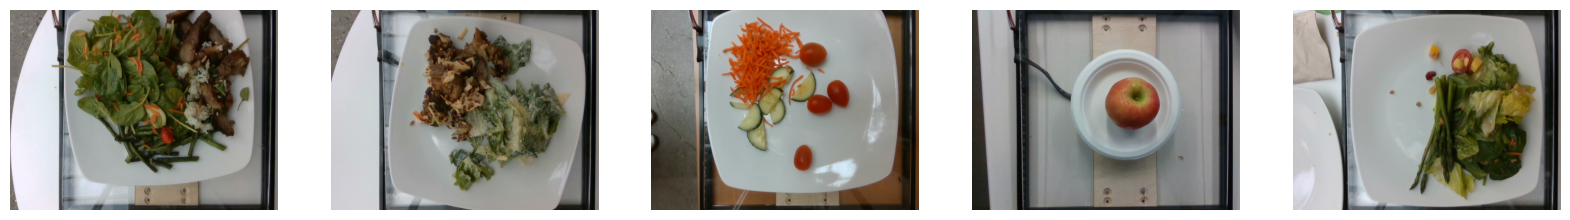

In [2]:
image_path = "data/images"

# Вывелем примеры пары изображений
from PIL import Image
from matplotlib import pyplot as plt

# Визуализация датасета до трансформаций
fig = plt.figure(figsize=(20,5))
for index in range (1, 6):
    image = f"{image_path}/{dish_df.loc[index, 'dish_id']}/rgb.png"
    label = dish_df.loc[index, "total_calories"]
    img = Image.open(image)
    print(label)
    plt.subplot(1, 5, index)
    plt.imshow(img)
    plt.axis('off')

In [3]:
"""
Сформируйте видение:
как вы будете решать задачу,
какие подходы к обогащению/аугментации данных примените и почему,
на какие метрики будете ориентироваться при обучении.
"""

msg = "Так как мы имеем дело не тлько с картинками, а с набором данных где есть и картинки и текст, нам понадобиться мультимодальная архитектура.\n" + \
"Для картинок мы можем использовать resnet50. Текстовая компонента модели будет обрабатывать список ингридиентов.\n" + \
"Обогащение и аугментация данных:\n" + \
"Визуальная аугментация: Так как у нас всего 2755 тренировочных примеров нужна аугментация,\n" + \
"или модель может заучить эти данные и показывать плохое качество на других примерах .\n" + \
"Можно применить цветовый искажения, повороты и отражения. Так как на многих фотографиях тарелка занимает все пространство от\n" + \
"верхнего края до нижнего, я бы не стала применять кроп трансорфмации для этого датасета. Тем более, что на некоторых из таких\n" + \
"снимков изображены различные ингридиенты, а это важная информация для обучения модели.\n" + \
"Для текста мы можем использовать перестановку ингридииентов местами, что добавит разнообразие вариантов.\n" + \
"В качестве выхода модели можно использовать total_calories/total_mass, что означает, что модели будет возвращать результат в\n" + \
"пределах диапозона от 0 до 1, что может помочь в обучении и стабилизации процесса.\n" + \
"Метрики: Для оценки качества модели будем использовать MAE. Если MAE < 50, это будет значит, что в среднем модель ошибается не более, чем на 50 калорий \n"
print(msg)

Так как мы имеем дело не тлько с картинками, а с набором данных где есть и картинки и текст, нам понадобиться мультимодальная архитектура.
Для картинок мы можем использовать resnet50. Текстовая компонента модели будет обрабатывать список ингридиентов.
Обогащение и аугментация данных:
Визуальная аугментация: Так как у нас всего 2755 тренировочных примеров нужна аугментация,
или модель может заучить эти данные и показывать плохое качество на других примерах .
Можно применить цветовый искажения, повороты и отражения. Так как на многих фотографиях тарелка занимает все пространство от
верхнего края до нижнего, я бы не стала применять кроп трансорфмации для этого датасета. Тем более, что на некоторых из таких
снимков изображены различные ингридиенты, а это важная информация для обучения модели.
Для текста мы можем использовать перестановку ингридииентов местами, что добавит разнообразие вариантов.
В качестве выхода модели можно использовать total_calories/total_mass, что означает, что модели

In [4]:
"""
Объедините таблицы dish.csv и ingredients.csv.
В колонке ingredients таблицы dish.csv хранятся технические идентификаторы вида ingr_0000000122 — модель не извлечёт из них никакой информации о блюде.  Замените идентификаторы на реальные названия продуктов из ingredients.csv (колонка ingr), чтобы текстовая компонента модели получала осмысленный вход.
Пример: "ingr_0000000122;ingr_0000000026" => "salmon, zucchini".
"""

for i in range(len(dish_df)):
    ingredients = dish_df.loc[i, "ingredients"].split(";")
    ingredients_str = []
    for ing in ingredients:
        index = int(ing[-3:])
        val = ing_df.loc[index-1, "ingr"]
        ingredients_str.append(val)
    dish_df.loc[i, "ingredients"] = ";".join(ingredients_str)



In [5]:
# Проверим как выглядит датасет после замены идентификаторов на названия ингридиентов
print(dish_df.loc[:5])

           dish_id  total_calories  total_mass  \
0  dish_1561662216      300.794281       193.0   
1  dish_1561662054      419.438782       292.0   
2  dish_1562008979      382.936646       290.0   
3  dish_1560455030       20.590000       103.0   
4  dish_1558372433       74.360001       143.0   
5  dish_1565640549       45.482903       139.0   

                                         ingredients  split  
0  soy sauce;garlic;white rice;parsley;onions;bro...   test  
1  pepper;white rice;mixed greens;garlic;soy sauc...  train  
2  jalapenos;lemon juice;pork;wheat berry;cabbage...   test  
3             cherry tomatoes;cucumbers;baby carrots  train  
4                                         deprecated  train  
5  tomatoes;cilantro;olive oil;mustard greens;lem...  train  


In [13]:

# Разделяем датасет на тренировочную и тестовую части. Обновляем индексы, чтобы они были от 0 до n-1 для каждой части датасета.
train_df = dish_df[dish_df["split"] == "train"].copy()
train_df.reset_index(drop=True, inplace=True)
val_df = dish_df[dish_df["split"] == "test"].copy()
val_df.reset_index(drop=True, inplace=True)

In [ ]:
"""
Этап 2. Реализуйте пайплайн обучения
Для корректной сборки монолитных py-файлов убедитесь, что в начале каждого файла собраны все нужные импорты.

Результат: Python-файл или файлы с воспроизводимым кодом обучения. 
Все результаты должны воспроизводиться путём вызова train с передачей конфигурационного файла.
"""

from utils_dl import train
import torch
from config import Config

conf = Config()

# Разделяем датасет на тренировочную и тестовую части. Обновляем индексы, чтобы они были от 0 до n-1 для каждой части датасета.
train_df = dish_df[dish_df["split"] == "train"].copy()
train_df.reset_index(drop=True, inplace=True)
val_df = dish_df[dish_df["split"] == "test"].copy()
val_df.reset_index(drop=True, inplace=True)
# Запускаем обучение модели
device = "cuda" if torch.cuda.is_available() else "cpu"
model = train(Config(), device,  train_df, val_df)

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Разморожен слой: encoder.layer.11.attention.self.query.weight
Разморожен слой: encoder.layer.11.attention.self.query.bias
Разморожен слой: encoder.layer.11.attention.self.key.weight
Разморожен слой: encoder.layer.11.attention.self.key.bias
Разморожен слой: encoder.layer.11.attention.self.value.weight
Разморожен слой: encoder.layer.11.attention.self.value.bias
Разморожен слой: encoder.layer.11.attention.output.dense.weight
Разморожен слой: encoder.layer.11.attention.output.dense.bias
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.bias
Разморожен слой: encoder.layer.11.intermediate.dense.weight
Разморожен слой: encoder.layer.11.intermediate.dense.bias
Разморожен слой: encoder.layer.11.output.dense.weight
Разморожен слой: encoder.layer.11.output.dense.bias
Разморожен слой: encoder.layer.11.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.output.LayerNorm.bias
Разморожен слой: pooler.dense.weight
Раз

In [7]:
"""
Этап 3. Модель обучена и сохранена в config.SAVE_PATH.
"""

'\nЭтап 3. Модель обучена и сохранена в config.SAVE_PATH.\n'

In [ ]:
""""
Этап 4. Валидация качества
"""
from utils_dl import MultimodalModel, DataLoader, partial, torchmetrics, AutoTokenizer
from dataset import MultimodalDataset, get_transforms, collate_fn
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Допишите код импорта и инференса предобученной модели 
model = MultimodalModel(conf)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load(conf.SAVE_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

print("Модель загружена и готова к работе")

Модель загружена и готова к работе


In [22]:
# Функция для получения предсказаний модели и сбора статистики по ошибкам для дальнейшего анализа
def get_model_results(model, val_loader, device, original_df):
    model.eval()
    results = []
    metric = torchmetrics.MeanAbsoluteError().to(device)
    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            # Получаем предсказания плотности и пересчитываем в калории
            preds_density = model(
                batch['input_ids'].to(device), 
                batch['attention_mask'].to(device),
                batch['image'].to(device)
            ).view(-1)
            
            # Предсказание: плотность * масса
            pred_calories = preds_density * batch['total_mass'].to(device)
            real_calories = batch['total_calories'].to(device)
            
            # Считаем разницу
            abs_loss = torch.abs(pred_calories - real_calories)
            metric.update(pred_calories, batch['total_calories'].to(device))
            
            # Сохраняем информацию об ошибках для анализа
            for j in range(len(batch['label'])):
                results.append({
                    'dish_id': original_df.iloc[i * val_loader.batch_size + j]['dish_id'],
                    'ingredients': original_df.iloc[i * val_loader.batch_size + j]['ingredients'],
                    'real': real_calories[j].item(),
                    'pred': pred_calories[j].item(),
                    'loss': abs_loss[j].item()
                })
    
    return results, metric.compute()

# Запустите модель на тестовом сплите данных test и выведите финальную целевую метрику по модели.
tokenizer = AutoTokenizer.from_pretrained(conf.TEXT_MODEL_NAME)
val_transforms = get_transforms(conf, ds_type="val")
val_dataset = MultimodalDataset(conf, val_transforms, val_df)
val_loader = DataLoader(val_dataset,
    batch_size=conf.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer))

results, final_metric = get_model_results(model, val_loader, device, val_df)
print(f"Final MAE: {final_metric:.4f}")

# Выведите топ-5 блюд, предсказанная калорийность которых значительно отличается от реальной. 

msg = "Для анализа топ-5 самых больших ошибок, отсортируем полученную статистику и посмотрим на каких данных модель ошибалась слабее и сильнее всего. Для каждого блюда выведем его ID, список ингридиентов, реальную калорийность, предсказанную калорийность и ошибку в калориях (MAE). Также загрузим и покажем фото блюда, чтобы визуально оценить, какие именно изображения были сложными для модели."
print(msg)

Final MAE: 42.4477
Для анализа топ-5 самых больших ошибок, отсортируем полученную статистику и посмотрим на каких данных модель ошибалась слабее и сильнее всего. Для каждого блюда выведем его ID, список ингридиентов, реальную калорийность, предсказанную калорийность и ошибку в калориях (MAE). Также загрузим и покажем фото блюда, чтобы визуально оценить, какие именно изображения были сложными для модели.


Top 15 худших результатов

ID блюда: dish_1566590007
Ингредиенты: bell peppers, garlic, tomatoes, salt, onions, olive oil, pizza, pepper, tofu, jalapenos, spinach (raw), chicken, millet
Реальные калории: 740.8
Предсказание: 975.1
Ошибка (MAE): 234.3


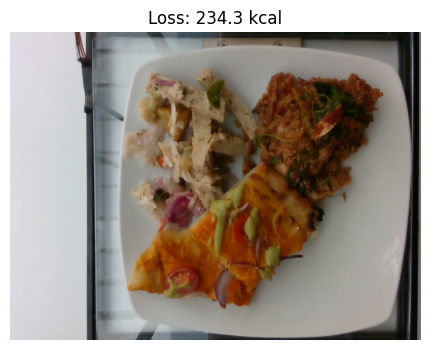


ID блюда: dish_1564675411
Ингредиенты: egg whites, turkey bacon
Реальные калории: 235.5
Предсказание: 471.2
Ошибка (MAE): 235.7


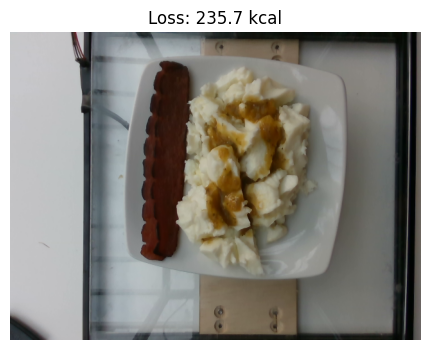


ID блюда: dish_1568401261
Ингредиенты: salt, squash, carrot, avocado, tuna salad, olive oil
Реальные калории: 530.4
Предсказание: 270.4
Ошибка (MAE): 260.0


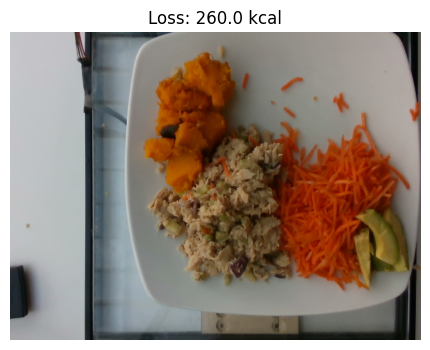


ID блюда: dish_1559844366
Ингредиенты: almonds, broccoli, grapes
Реальные калории: 529.2
Предсказание: 256.8
Ошибка (MAE): 272.5


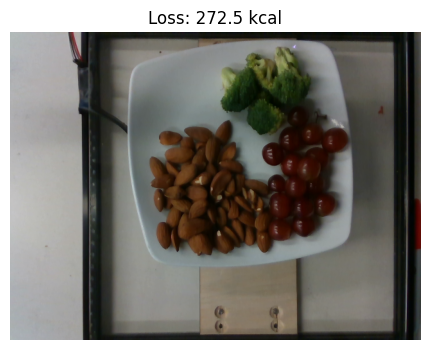


ID блюда: dish_1568401199
Ингредиенты: tuna salad, squash, olive oil, salt
Реальные калории: 459.6
Предсказание: 184.0
Ошибка (MAE): 275.6


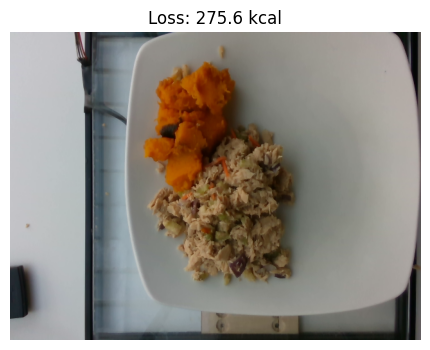


ID блюда: dish_1558375886
Ингредиенты: almonds, sausage, grapes
Реальные калории: 1050.5
Предсказание: 774.4
Ошибка (MAE): 276.1


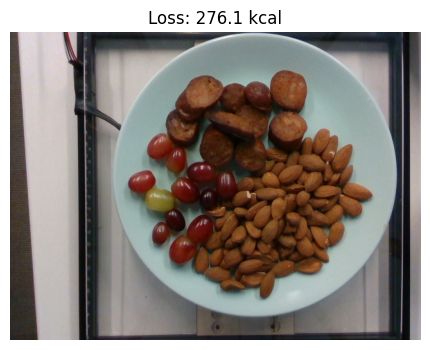


ID блюда: dish_1568401233
Ингредиенты: salt, squash, carrot, tuna salad, olive oil
Реальные калории: 490.4
Предсказание: 205.9
Ошибка (MAE): 284.5


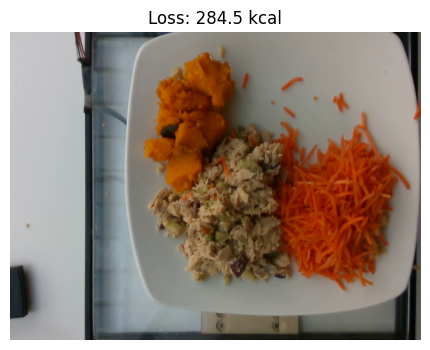


ID блюда: dish_1568401302
Ингредиенты: fried rice, salt, squash, carrot, avocado, olive oil, tuna salad
Реальные калории: 716.5
Предсказание: 428.8
Ошибка (MAE): 287.6


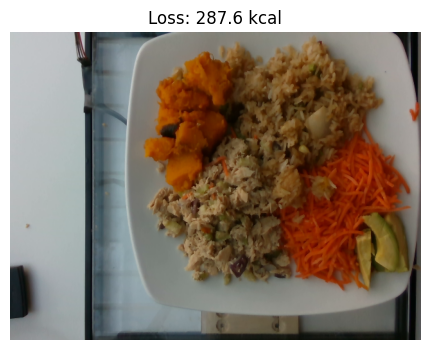


ID блюда: dish_1566328805
Ингредиенты: cherry tomatoes, pizza, chicken, pineapple
Реальные калории: 927.8
Предсказание: 634.8
Ошибка (MAE): 293.0


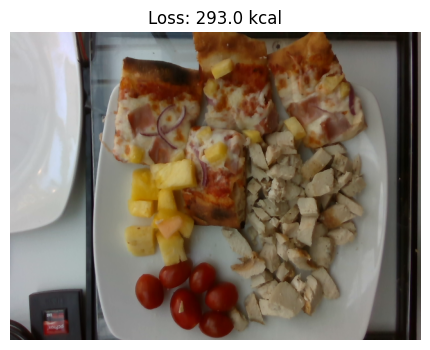


ID блюда: dish_1559849466
Ингредиенты: pears, almonds
Реальные калории: 467.6
Предсказание: 761.3
Ошибка (MAE): 293.7


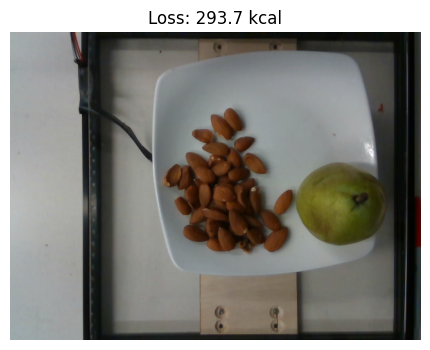


ID блюда: dish_1565811139
Ингредиенты: carrot, goat cheese, olive oil, broccoli, spinach (raw), chicken
Реальные калории: 902.2
Предсказание: 589.5
Ошибка (MAE): 312.7


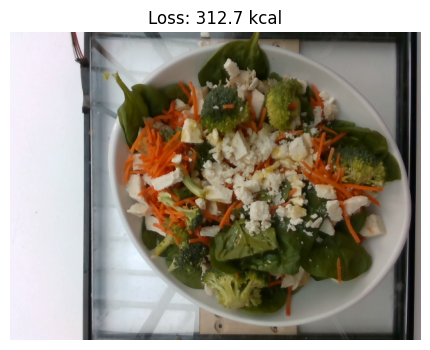


ID блюда: dish_1566501594
Ингредиенты: brownies
Реальные калории: 508.0
Предсказание: 132.2
Ошибка (MAE): 375.9


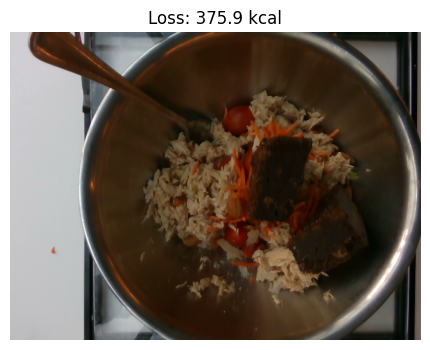


ID блюда: dish_1558630325
Ингредиенты: apple, garden salad, almonds
Реальные калории: 751.5
Предсказание: 304.8
Ошибка (MAE): 446.7


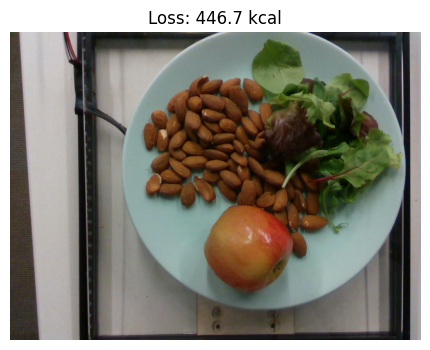


ID блюда: dish_1558549806
Ингредиенты: almonds, white rice, spinach (raw)
Реальные калории: 782.0
Предсказание: 296.9
Ошибка (MAE): 485.1


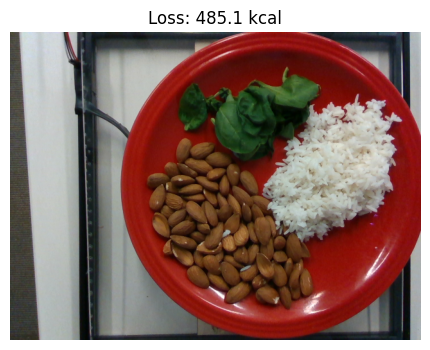


ID блюда: dish_1558720236
Ингредиенты: apple, carrot, cauliflower, almonds
Реальные калории: 887.8
Предсказание: 346.9
Ошибка (MAE): 541.0


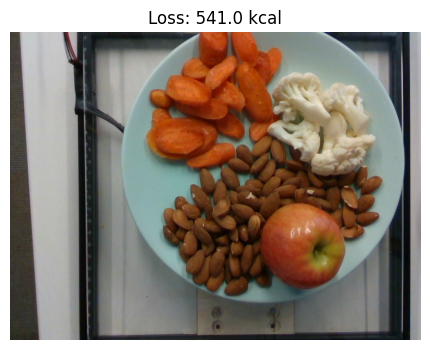

In [25]:
def analyze_results(results):
    for item in results:
        print(f"\n{'='*50}")
        print(f"ID блюда: {item['dish_id']}")
        print(f"Ингредиенты: {item['ingredients'].replace(';', ', ')}")
        print(f"Реальные калории: {item['real']:.1f}")
        print(f"Предсказание: {item['pred']:.1f}")
        print(f"Ошибка (MAE): {item['loss']:.1f}")
        
        # Загрузка и показ фото
        img_path = f"data/images/{item['dish_id']}/rgb.png"
        try:
            img = Image.open(img_path)
            plt.figure(figsize=(6, 4))
            plt.imshow(img)
            plt.title(f"Loss: {item['loss']:.1f} kcal")
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print("Фото не найдено.")


sortet_results = sorted(results, key=lambda x: x['loss'])
top_15_best = sortet_results[:15]
top_15_worst = sortet_results[-15:]
top_5_worst = sortet_results[-5:]

print("Top 15 худших результатов")
analyze_results(top_15_worst)


Top 15 лучших результатов

ID блюда: dish_1558110335
Ингредиенты: bacon
Реальные калории: 37.9
Предсказание: 37.9
Ошибка (MAE): 0.0


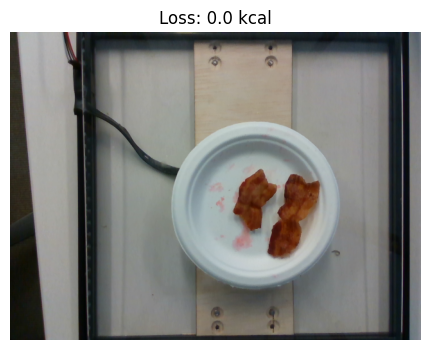


ID блюда: dish_1563294987
Ингредиенты: bacon
Реальные калории: 97.4
Предсказание: 97.4
Ошибка (MAE): 0.0


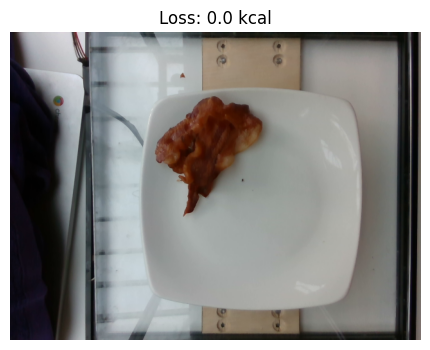


ID блюда: dish_1563897938
Ингредиенты: bacon
Реальные калории: 54.1
Предсказание: 54.1
Ошибка (MAE): 0.0


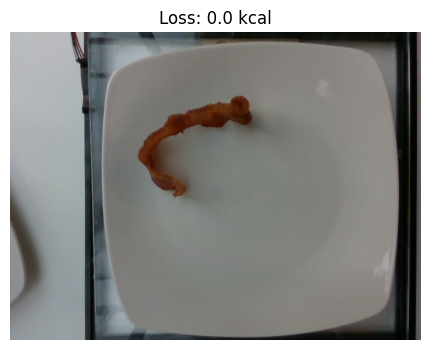


ID блюда: dish_1557937335
Ингредиенты: yam
Реальные калории: 47.2
Предсказание: 47.1
Ошибка (MAE): 0.0


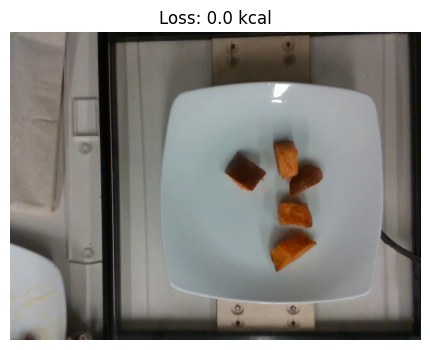


ID блюда: dish_1559578551
Ингредиенты: bacon
Реальные калории: 124.4
Предсказание: 124.4
Ошибка (MAE): 0.0


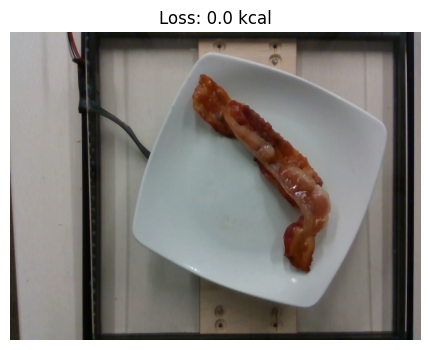


ID блюда: dish_1565020755
Ингредиенты: bacon
Реальные калории: 43.3
Предсказание: 43.3
Ошибка (MAE): 0.0


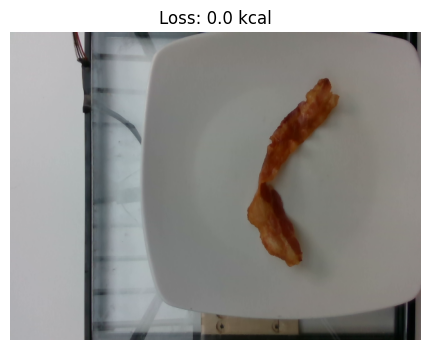


ID блюда: dish_1562690950
Ингредиенты: pineapple, broccoli, berries, olive oil
Реальные калории: 109.1
Предсказание: 109.1
Ошибка (MAE): 0.1


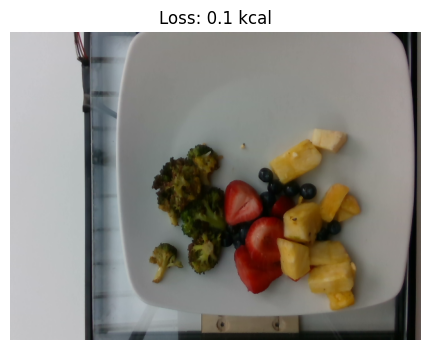


ID блюда: dish_1557937574
Ингредиенты: blackberries
Реальные калории: 5.6
Предсказание: 5.7
Ошибка (MAE): 0.1


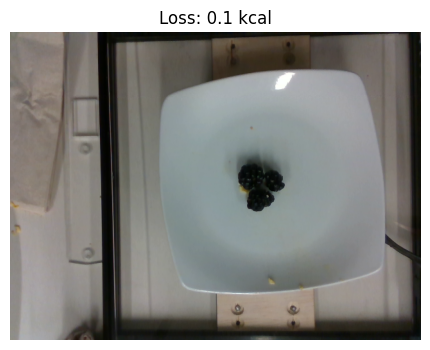


ID блюда: dish_1558376801
Ингредиенты: mixed greens
Реальные калории: 4.2
Предсказание: 4.3
Ошибка (MAE): 0.1


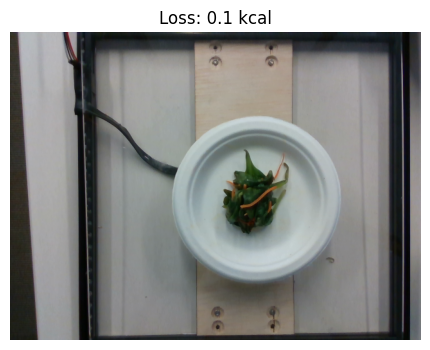


ID блюда: dish_1558113430
Ингредиенты: mixed greens
Реальные калории: 7.8
Предсказание: 7.9
Ошибка (MAE): 0.1


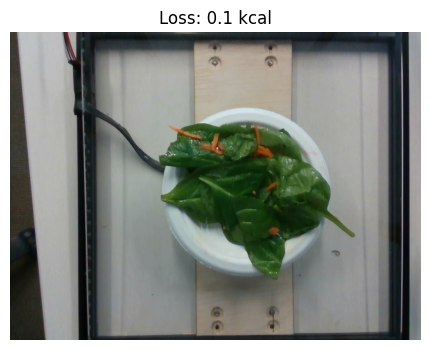


ID блюда: dish_1559233627
Ингредиенты: bacon
Реальные калории: 64.9
Предсказание: 65.0
Ошибка (MAE): 0.1


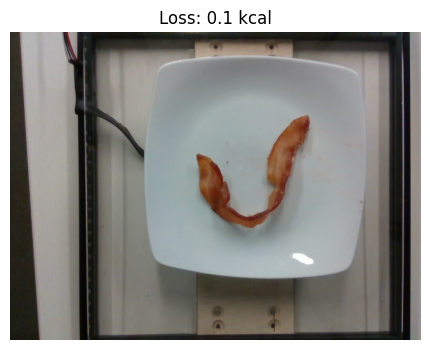


ID блюда: dish_1565974375
Ингредиенты: bacon
Реальные калории: 459.8
Предсказание: 460.0
Ошибка (MAE): 0.1


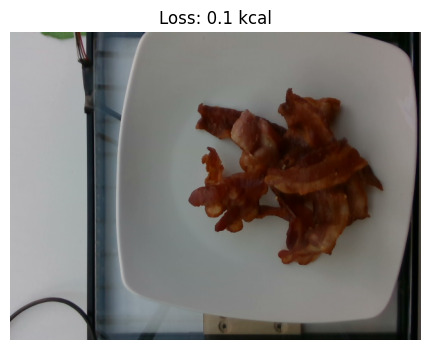


ID блюда: dish_1558030383
Ингредиенты: bacon
Реальные калории: 140.7
Предсказание: 140.8
Ошибка (MAE): 0.1


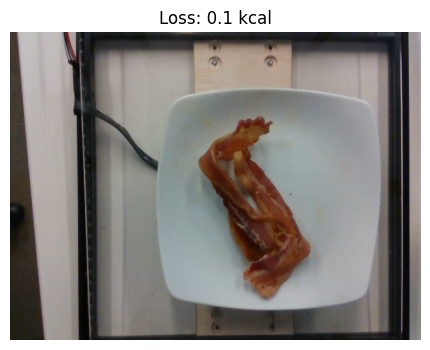


ID блюда: dish_1565034605
Ингредиенты: lettuce, mixed greens, lime, olive oil, vinegar, cucumbers, onions, pepper, salt, cherry tomatoes
Реальные калории: 52.5
Предсказание: 52.6
Ошибка (MAE): 0.1


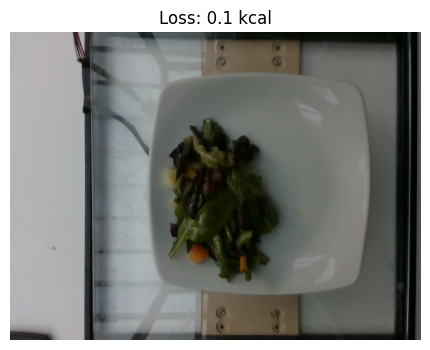


ID блюда: dish_1558718587
Ингредиенты: cauliflower
Реальные калории: 10.2
Предсказание: 10.4
Ошибка (MAE): 0.2


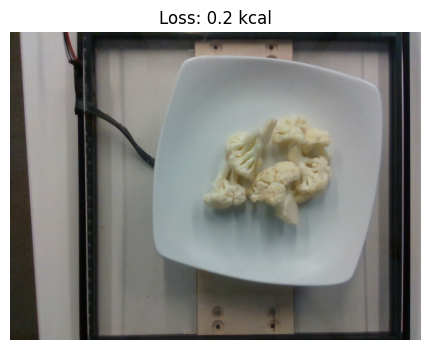

In [29]:

print("Top 15 лучших результатов")
analyze_results(top_15_best)


Top 5 худших результатов

ID блюда: dish_1565811139
Ингредиенты: carrot, goat cheese, olive oil, broccoli, spinach (raw), chicken
Реальные калории: 902.2
Предсказание: 589.5
Ошибка (MAE): 312.7


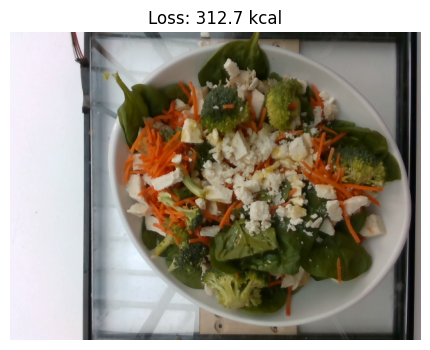


ID блюда: dish_1566501594
Ингредиенты: brownies
Реальные калории: 508.0
Предсказание: 132.2
Ошибка (MAE): 375.9


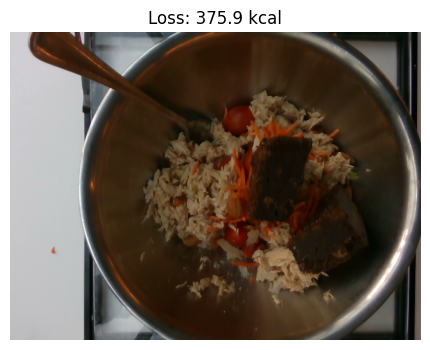


ID блюда: dish_1558630325
Ингредиенты: apple, garden salad, almonds
Реальные калории: 751.5
Предсказание: 304.8
Ошибка (MAE): 446.7


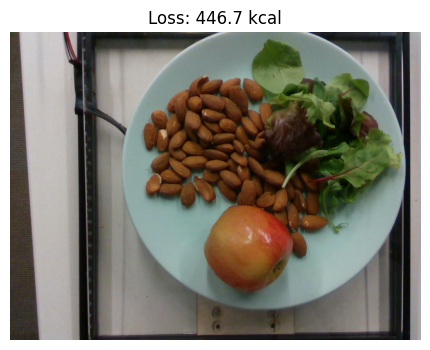


ID блюда: dish_1558549806
Ингредиенты: almonds, white rice, spinach (raw)
Реальные калории: 782.0
Предсказание: 296.9
Ошибка (MAE): 485.1


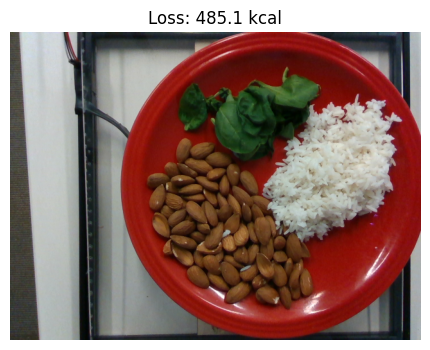


ID блюда: dish_1558720236
Ингредиенты: apple, carrot, cauliflower, almonds
Реальные калории: 887.8
Предсказание: 346.9
Ошибка (MAE): 541.0


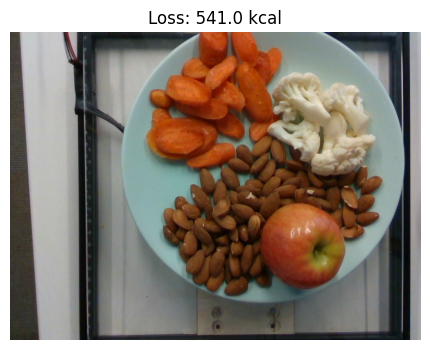

In [30]:

print("Top 5 худших результатов")
analyze_results(top_5_worst)


In [37]:
"""
Описаны возможные причины низкого качества на этих примерах. 
"""

msg = "Возможные причины низкого качества: модель хорошо справляется с изображениями, где изображен один ингридиент,\n" + \
"если он достаточно узнаваем. На примерах выше присутсвует несколько ингридиентов, некоторые из них очень тяжело или\n" + \
"невозможно определить по фото даже человеку. Например: масло, уксус, другие заправки.\n" + \
"Модели сложно когда ингридииенты смешны в одну кучу, а не лежат отдельными группами.\n" + \
"Так же на примерах выше посуда не стандартная и не белая/светлая. На одном примере железная миска,\n"+ \
"на другом красная тарелка. Это могло повлиять на распознование объектов.\n" + \
"Есть пример с неправильными ингридиентами, например brownies на втором изображении, на котором явно больше одного ингридиента.\n" + \
"На примерах с миндалем модель сильно занижает количество калорий, вероятно из-за цвета и формы может быть сложно определить сам\n" + \
"ингридиент и его границы. Так же возможно модель плохо выучила калораж некоторых продуктов по этой причине и как следствие\n" + \
"выдает не точные результаты."

print(msg)

Возможные причины низкого качества: модель хорошо справляется с изображениями, где изображен один ингридиент,
если он достаточно узнаваем. На примерах выше присутсвует несколько ингридиентов, некоторые из них очень тяжело или
невозможно определить по фото даже человеку. Например: масло, уксус, другие заправки.
Модели сложно когда ингридииенты смешны в одну кучу, а не лежат отдельными группами.
Так же на примерах выше посуда не стандартная и не белая/светлая. На одном примере железная миска,
на другом красная тарелка. Это могло повлиять на распознование объектов.
Есть пример с неправильными ингридиентами, например brownies на втором изображении, на котором явно больше одного ингридиента.
На примерах с миндалем модель сильно занижает количество калорий, вероятно из-за цвета и формы может быть сложно определить сам
ингридиент и его границы. Так же возможно модель плохо выучила калораж некоторых продуктов по этой причине и как следствие
выдает не точные результаты.
